# 📊 Analysis of Delivery and Feedback Data for Six Products

## 🗂 Dataset Description  
This dataset contains delivery and customer feedback information for six products sold by a company.

---

## ❓ Key Questions  
1. Are there any issues with the delivery service?  
2. Are there any sales regions with untapped potential?  
3. Are there any product quality concerns?

---


## 🔧 Analysis Process

### 1️⃣ Data Cleaning  
- Removed duplicates  
- Handled missing values  
- Standardized formatting  
- Treated outliers:  
  - Sales amount equal to 0  
  - Sales quantity and amount with standard deviations exceeding 8 times the mean

---

### 2️⃣ Data Structuring  
- Created auxiliary columns (e.g., **month**) for time-based analysis

---

### 3️⃣ Data Analysis & Visualization  
- Compared delivery timeliness and rejection rates by product and region  
- Evaluated sales potential and growth space by region  
- Analyzed product quality using feedback data (e.g., rework and rejection rates)



In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 


# 1. Data Cleaning  
① Duplicate values, missing values, and format adjustments

In [3]:
data = pd.read_csv('/Users/jinyichen/Downloads/logistics_data.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1161 entries, 0 to 1160
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 1159 non-null   object 
 1   Order_Line               1161 non-null   int64  
 2   Sales_Date               1161 non-null   object 
 3   Delivery_Date            1161 non-null   object 
 4   Product_Delivery_Status  1159 non-null   object 
 5   Product                  1161 non-null   object 
 6   Product_Feedback         1161 non-null   object 
 7   Sales_Region             1161 non-null   object 
 8   Quantity                 1157 non-null   float64
 9   Sales_Amount             1161 non-null   object 
dtypes: float64(1), int64(1), object(8)
memory usage: 90.8+ KB


## 🧹 Initial Data Inspection with `info()`

The dataset contains **10 columns**, including column names, data types, and non-null counts.

---

### 🔍 Key Observations:

1. **Order ID**, **Product Delivery Status**, and **Quantity** contain **missing values**.  
   → However, the proportion is small, so **rows with missing values can be safely dropped**.

2. **Order Line** is **not relevant for analysis**,  
   → It can be **dropped** to simplify the dataset.

3. **Sales Amount** contains mixed units (e.g., "yuan" and "thousand yuan") and inconsistent formatting with commas.  
   → The column should be cleaned and converted to numeric format.

In [4]:
#delete duplicate values
data.drop_duplicates(keep='first',inplace=True)
#delete na value
data.dropna(axis=0,how='any',inplace=True)
#delete unnecessary column
data.drop(columns=['Order_Line'],inplace=True,axis=1)
print(data.info())
# Update the index (drop=True: remove the old index column and reset to default)
data.reset_index(drop=True,inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1137 entries, 0 to 1160
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 1137 non-null   object 
 1   Sales_Date               1137 non-null   object 
 2   Delivery_Date            1137 non-null   object 
 3   Product_Delivery_Status  1137 non-null   object 
 4   Product                  1137 non-null   object 
 5   Product_Feedback         1137 non-null   object 
 6   Sales_Region             1137 non-null   object 
 7   Quantity                 1137 non-null   float64
 8   Sales_Amount             1137 non-null   object 
dtypes: float64(1), object(8)
memory usage: 88.8+ KB
None


### 💰 Cleaning Sales Amount
- Extract the **Sales Amount** column.
- data uses a dot (.) as the decimal point without commas, and the unit is either the word **"thousand"** or no unit at all.
- Define a custom function to:
  - Remove commas.
  - Convert the value to a float.
  - If the unit contains the word **"thousand"**, multiply the number by 1,000.  
  - If not, keep the original values.

In [5]:
def data_deal(number):
    if 'thousand' in number:
    
        num = float(number.replace('thousand', ''))
        number_new = round(num * 1000, 2)
    else:
   
        number_new = round(float(number), 2)
    return number_new

data['Sales_Amount'] = data['Sales_Amount'].map(data_deal)

In [6]:
data

,Order_ID,Sales_Date,Delivery_Date,Product_Delivery_Status,Product,Product_Feedback,Sales_Region,Quantity,Sales_Amount
0,P096311,2016-7-30,2016-9-30,Late delivery,Product3,Quality Passed,North China,2.0,1052.75
1,P096826,2016-8-30,2016-10-30,On time delivery,Product3,Quality Passed,North China,10.0,115000.00
2,P097435,2016-7-30,2016-9-30,On time delivery,Product1,Rework,South China,2.0,6858.77
3,P097446,2016-11-26,2017-1-26,Late delivery,Product3,Quality Passed,North China,15.0,129.58
4,P097446,2016-11-26,2017-1-26,Late delivery,Product3,Rejected,North China,15.0,32.39
...,...,...,...,...,...,...,...,...,...
1132,P299901,2016-12-15,2017-3-15,On time delivery,Product6,Quality Passed,Malaysia,2.0,200.41
1133,P302956,2016-12-22,2017-3-22,On time delivery,Product2,Rejected,East China,20.0,79.44
1134,P303801,2016-12-15,2017-3-15,On time delivery,Product2,Quality Passed,East China,1.0,194.08
1135,P307276,2016-12-22,2017-3-22,On time delivery,Product6,Quality Passed,Malaysia,1.0,32.18


② Outlier Handling
- Remove cases where the Sales Amount is zero.

In [7]:
print(data.describe())

           Quantity   Sales_Amount
count   1137.000000    1137.000000
mean      76.655673    1226.090950
std      591.709671   11188.374251
min        1.000000       0.000000
25%        1.000000      29.400000
50%        1.000000      94.020000
75%        4.000000     357.730000
max    11500.000000  327000.000000


In [8]:
data = data[data['Sales_Amount']!=0]
data

,Order_ID,Sales_Date,Delivery_Date,Product_Delivery_Status,Product,Product_Feedback,Sales_Region,Quantity,Sales_Amount
0,P096311,2016-7-30,2016-9-30,Late delivery,Product3,Quality Passed,North China,2.0,1052.75
1,P096826,2016-8-30,2016-10-30,On time delivery,Product3,Quality Passed,North China,10.0,115000.00
2,P097435,2016-7-30,2016-9-30,On time delivery,Product1,Rework,South China,2.0,6858.77
3,P097446,2016-11-26,2017-1-26,Late delivery,Product3,Quality Passed,North China,15.0,129.58
4,P097446,2016-11-26,2017-1-26,Late delivery,Product3,Rejected,North China,15.0,32.39
...,...,...,...,...,...,...,...,...,...
1132,P299901,2016-12-15,2017-3-15,On time delivery,Product6,Quality Passed,Malaysia,2.0,200.41
1133,P302956,2016-12-22,2017-3-22,On time delivery,Product2,Rejected,East China,20.0,79.44
1134,P303801,2016-12-15,2017-3-15,On time delivery,Product2,Quality Passed,East China,1.0,194.08
1135,P307276,2016-12-22,2017-3-22,On time delivery,Product6,Quality Passed,Malaysia,1.0,32.18


# 2. Data Structuring

In [9]:
data['Sales_Date'] = pd.to_datetime(data['Sales_Date'])
data['Month'] = data['Sales_Date'].apply(lambda x:x.month)
data

/var/folders/dy/f6cx3q_97zbd50n9q4xsz_nc0000gn/T/ipykernel_64094/2461277587.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Sales_Date'] = pd.to_datetime(data['Sales_Date'])
/var/folders/dy/f6cx3q_97zbd50n9q4xsz_nc0000gn/T/ipykernel_64094/2461277587.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Month'] = data['Sales_Date'].apply(lambda x:x.month)


,Order_ID,Sales_Date,Delivery_Date,Product_Delivery_Status,Product,Product_Feedback,Sales_Region,Quantity,Sales_Amount,Month
0,P096311,2016-07-30,2016-9-30,Late delivery,Product3,Quality Passed,North China,2.0,1052.75,7
1,P096826,2016-08-30,2016-10-30,On time delivery,Product3,Quality Passed,North China,10.0,115000.00,8
2,P097435,2016-07-30,2016-9-30,On time delivery,Product1,Rework,South China,2.0,6858.77,7
3,P097446,2016-11-26,2017-1-26,Late delivery,Product3,Quality Passed,North China,15.0,129.58,11
4,P097446,2016-11-26,2017-1-26,Late delivery,Product3,Rejected,North China,15.0,32.39,11
...,...,...,...,...,...,...,...,...,...,...
1132,P299901,2016-12-15,2017-3-15,On time delivery,Product6,Quality Passed,Malaysia,2.0,200.41,12
1133,P302956,2016-12-22,2017-3-22,On time delivery,Product2,Rejected,East China,20.0,79.44,12
1134,P303801,2016-12-15,2017-3-15,On time delivery,Product2,Quality Passed,East China,1.0,194.08,12
1135,P307276,2016-12-22,2017-3-22,On time delivery,Product6,Quality Passed,Malaysia,1.0,32.18,12


# 3. Data Analysis and Visualization  
  1. Are there issues with the delivery service?  

  - a. Analyze by month

In [10]:

data['Product_Delivery_Status'] = data['Product_Delivery_Status'].str.strip()


data1 = data.groupby(['Month', 'Product_Delivery_Status']).size().unstack(fill_value=0)


data1['On_Time_Delivery_Rate'] = data1['On time delivery'] / (
    data1['On time delivery'] + data1['Late delivery']
)


/var/folders/dy/f6cx3q_97zbd50n9q4xsz_nc0000gn/T/ipykernel_64094/1926236410.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Product_Delivery_Status'] = data['Product_Delivery_Status'].str.strip()


In [11]:
data1

Product_Delivery_Status,Late delivery,On time delivery,On_Time_Delivery_Rate
Month,,,
7,13,189,0.935644
8,34,213,0.862348
9,9,122,0.931298
10,31,236,0.883895
11,25,101,0.801587
12,17,146,0.895706


- b. Analyze by region

In [12]:
data1 = data.groupby(['Sales_Region','Product_Delivery_Status']).size().unstack()
data1['On_Time_Delivery_Rate'] = data1['On time delivery']/(data1['On time delivery']+data1['Late delivery'])
print(data1.sort_values(by='On_Time_Delivery_Rate',ascending=False))

# There is a prominent issue of delayed deliveries in the Northwest China that urgently needs to be addressed.

Product_Delivery_Status  Late delivery  On time delivery  \
Sales_Region                                               
Thailand                             4               181   
Malaysia                            15               306   
South China                          1                10   
North China                         27               226   
East China                          38               268   
Northwest China                     44                16   

Product_Delivery_Status  On_Time_Delivery_Rate  
Sales_Region                                    
Thailand                              0.978378  
Malaysia                              0.953271  
South China                           0.909091  
North China                           0.893281  
East China                            0.875817  
Northwest China                       0.266667  


- c. Analyze by product

In [13]:
data1 = data.groupby(['Product','Product_Delivery_Status']).size().unstack()
data1['On_Time_Delivery_Rate'] = data1['On time delivery']/(data1['On time delivery']+data1['Late delivery'])
print(data1.sort_values(by='On_Time_Delivery_Rate',ascending=False))
#Product 4 has a serious issue with delayed deliveries, while the other products are performing normally.

Product_Delivery_Status  Late delivery  On time delivery  \
Product                                                    
Product5                             4               181   
Product6                             7               305   
Product1                             2                27   
Product3                            26               212   
Product2                            46               269   
Product4                            44                13   

Product_Delivery_Status  On_Time_Delivery_Rate  
Product                                         
Product5                              0.978378  
Product6                              0.977564  
Product1                              0.931034  
Product3                              0.890756  
Product2                              0.853968  
Product4                              0.228070  


- d. Analyze by Combination of Product and Sales Region


In [14]:
data1 = data.groupby(['Product','Sales_Region','Product_Delivery_Status']).size().unstack()
data1['On_Time_Delivery_Rate'] = data1['On time delivery']/(data1['On time delivery']+data1['Late delivery'])
print(data1.sort_values(by='On_Time_Delivery_Rate',ascending=False))

Product_Delivery_Status   Late delivery  On time delivery  \
Product  Sales_Region                                       
Product5 Thailand                   4.0             181.0   
Product6 Malaysia                   7.0             305.0   
Product1 North China                1.0              14.0   
         South China                1.0              10.0   
Product3 North China               26.0             212.0   
Product2 East China                38.0             268.0   
Product4 Northwest China           44.0              13.0   
Product2 Malaysia                   8.0               1.0   
Product1 Northwest China            NaN               3.0   

Product_Delivery_Status   On_Time_Delivery_Rate  
Product  Sales_Region                            
Product5 Thailand                      0.978378  
Product6 Malaysia                      0.977564  
Product1 North China                   0.933333  
         South China                   0.909091  
Product3 North China        

### 📊 Analysis by Product and Sales Region

- **Sales Region:**  
  The **Northwest region** has the **worst delivery performance**, mainly involving **Product 1** and **Product 4**.  
  The primary reason is the **frequent late deliveries of Product 4**.

- **Product:**  
  **Product 2** shows the **worst overall delivery status**.  
  It is mainly delivered to **East China** and **Malaysia**, with the delays **mostly coming from deliveries to Malaysia**.

  

### 🔍 2. Are There Sales Regions with Untapped Potential?

- a. Monthly Dimension

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


<Axes: xlabel='Month'>

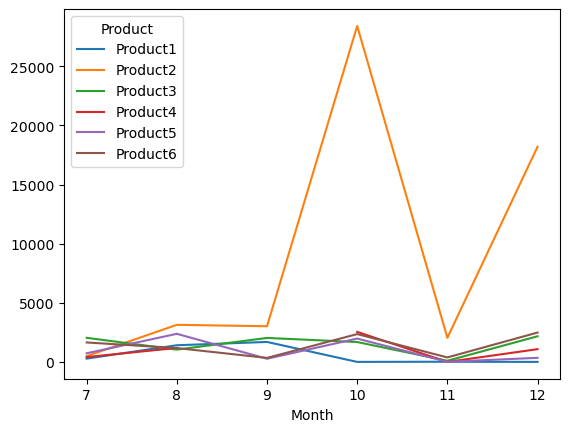

In [15]:
data1 = data.groupby(['Month','Product'])['Quantity'].sum().unstack()
data1.plot(kind='line')

### 📈 Product 2 Sales Surge in October and December

Possible reasons:  
1. Increased marketing efforts by the company during these months  
2. Expansion into new markets (to be validated in subsequent analysis)

- 2.b Regional Dimension

Analyze sales volume by region to explore potential markets.


In [16]:
data1 = data.groupby(['Sales_Region','Product'])['Quantity'].sum().unstack()
data1

Product,Product1,Product2,Product3,Product4,Product5,Product6
Sales_Region,,,,,,
East China,NaN,53810.0,NaN,NaN,NaN,NaN
Malaysia,NaN,1509.0,NaN,NaN,NaN,8394.0
North China,2827.0,NaN,9073.5,NaN,NaN,NaN
Northwest China,11.0,NaN,NaN,5228.0,NaN,NaN
South China,579.0,NaN,NaN,NaN,NaN,NaN
Thailand,NaN,NaN,NaN,NaN,5725.0,NaN


# 📊 Regional Distribution by Product

Each product is sold in 1 to 3 regions.  
- Product 1 is sold in **three** regions.  
- Product 2 is sold in **two** regions.  
- The remaining products are sold in **one** region each.

- c.Monthly and Regional Sales

In [17]:
data1 = data.groupby(['Month','Sales_Region','Product'])['Quantity'].sum().unstack()
data1['Product2']

Month  Sales_Region   
7      East China           489.0
       Malaysia               2.0
       North China            NaN
       Northwest China        NaN
       South China            NaN
       Thailand               NaN
8      East China          1640.0
       Malaysia            1502.0
       North China            NaN
       Northwest China        NaN
       South China            NaN
       Thailand               NaN
9      East China          3019.0
       Malaysia               1.0
       North China            NaN
       Northwest China        NaN
       South China            NaN
       Thailand               NaN
10     East China         28420.0
       Malaysia               NaN
       North China            NaN
       Northwest China        NaN
       Thailand               NaN
11     East China          2041.0
       Malaysia               1.0
       North China            NaN
       Northwest China        NaN
       South China            NaN
       Thailand          

- Product 2 experienced a sharp sales increase in October and December, mainly in its existing sales region (East China).  
- Similarly, analysis shows that in July, August, September, and November, there is still significant potential for sales growth, so marketing efforts can be appropriately increased during these months.

## 3. Are there any quality issues with the products?

In [19]:
data['Product_Feedback'] = data['Product_Feedback'].str.strip()  
data1 = data.groupby(['Product','Sales_Region'])['Product_Feedback'].value_counts().unstack()
data1['Rejected_rate'] = data1['Rejected'] /data1.sum(axis=1)  
data1['Rework_rate'] = data1['Rework'] /data1.sum(axis=1)
data1['Pass_rate'] = data1['Quality Passed'] /data1.sum(axis=1)
data1.sort_values(['Pass_rate','Rework_rate','Rejected_rate'],ascending=False)

/var/folders/dy/f6cx3q_97zbd50n9q4xsz_nc0000gn/T/ipykernel_64094/94571476.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Product_Feedback'] = data['Product_Feedback'].str.strip()


Product_Feedback          Quality Passed  Rejected  Rework  Rejected_rate  \
Product  Sales_Region                                                       
Product3 North China               188.0      31.0    19.0       0.130252   
Product6 Malaysia                  242.0      56.0    14.0       0.179487   
Product5 Thailand                  142.0      14.0    29.0       0.075676   
Product2 East China                184.0      71.0    51.0       0.232026   
Product1 South China                 4.0       5.0     2.0       0.454545   
         Northwest China             1.0       NaN     2.0            NaN   
         North China                 3.0       NaN    12.0            NaN   
Product4 Northwest China             9.0       NaN    48.0            NaN   
Product2 Malaysia                    1.0       6.0     2.0       0.666667   

Product_Feedback          Rework_rate  Pass_rate  
Product  Sales_Region                             
Product3 North China         0.079788   0.789219  
Product6 Malaysia            0.044846   0.775084  
Product5 Thailand            0.156693   0.766605  
Product2 East China          0.166540   0.600525  
Product1 South China         0.174603   0.343963  
         Northwest China     0.666667   0.272727  
         North China         0.800000   0.189873  
Product4 Northwest China     0.842105   0.155596  
Product2 Malaysia            0.206897   0.101281

In [ ]:
- Products 3, 6, and 5 have high pass rates and low repair rates, indicating good quality.  
- Products 1, 2, and 4 have lower pass rates and higher repair rates, suggesting quality issues that need improvement.  
- Product 2 has the highest rejection rate in Malaysia, and its on-time delivery rate there is also very low. It is suspected that customers in Malaysia have higher demands for delivery timeliness, and if unmet, they often refuse the goods.  
- Considering that product 2 has large sales volumes in the East China region, it might be wise to increase investment in East China while reducing investment in Malaysia accordingly.